In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("smartcart_customers.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
df.shape

(2240, 22)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# data preprosessing


In [ ]:
## handles the missing values

In [9]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [11]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# feature enginnerings 

In [19]:
# Age

df["Age"] = 2026-df["Year_Birth"]

In [20]:
#Costumer_tenure_days

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Costumer_tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

In [21]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_tenure_date,Costumer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,161


In [22]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Costumer_tenure_date',
       'Costumer_tenure_days'],
      dtype='object')

In [29]:
df["Total_spending"] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts']+ df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [30]:
df["Total_children"] = df['Kidhome'] + df['Teenhome'] 

In [34]:
# Education 

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle ": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate","PhD": "Postgraduate"
})



In [43]:
#marital status

df['Marital_Status'].value_counts()

df["Living_with"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone","Absurd": "Alone" ,"YOLO": "Alone"
})

In [44]:
df['Living_with'].value_counts()


Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [125]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_tenure_date,Costumer_tenure_days,Total_spending,Total_children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,1,69,663,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,72,113,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,61,312,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,42,139,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,45,161,161,422,1,Partner


# drop column


In [126]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Costumer_tenure_date',
       'Costumer_tenure_days', 'Total_spending', 'Total_children',
       'Living_with'],
      dtype='object')

In [127]:
cols = ["ID","Year_Birth" , 'Marital_Status','Kidhome','Teenhome' ,'Dt_Customer','Costumer_tenure_date']

spending_cols = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [128]:
df_cleaned.shape

(2240, 15)

In [129]:
df.shape

(2240, 28)

In [130]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_tenure_days,Total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


#outliers 



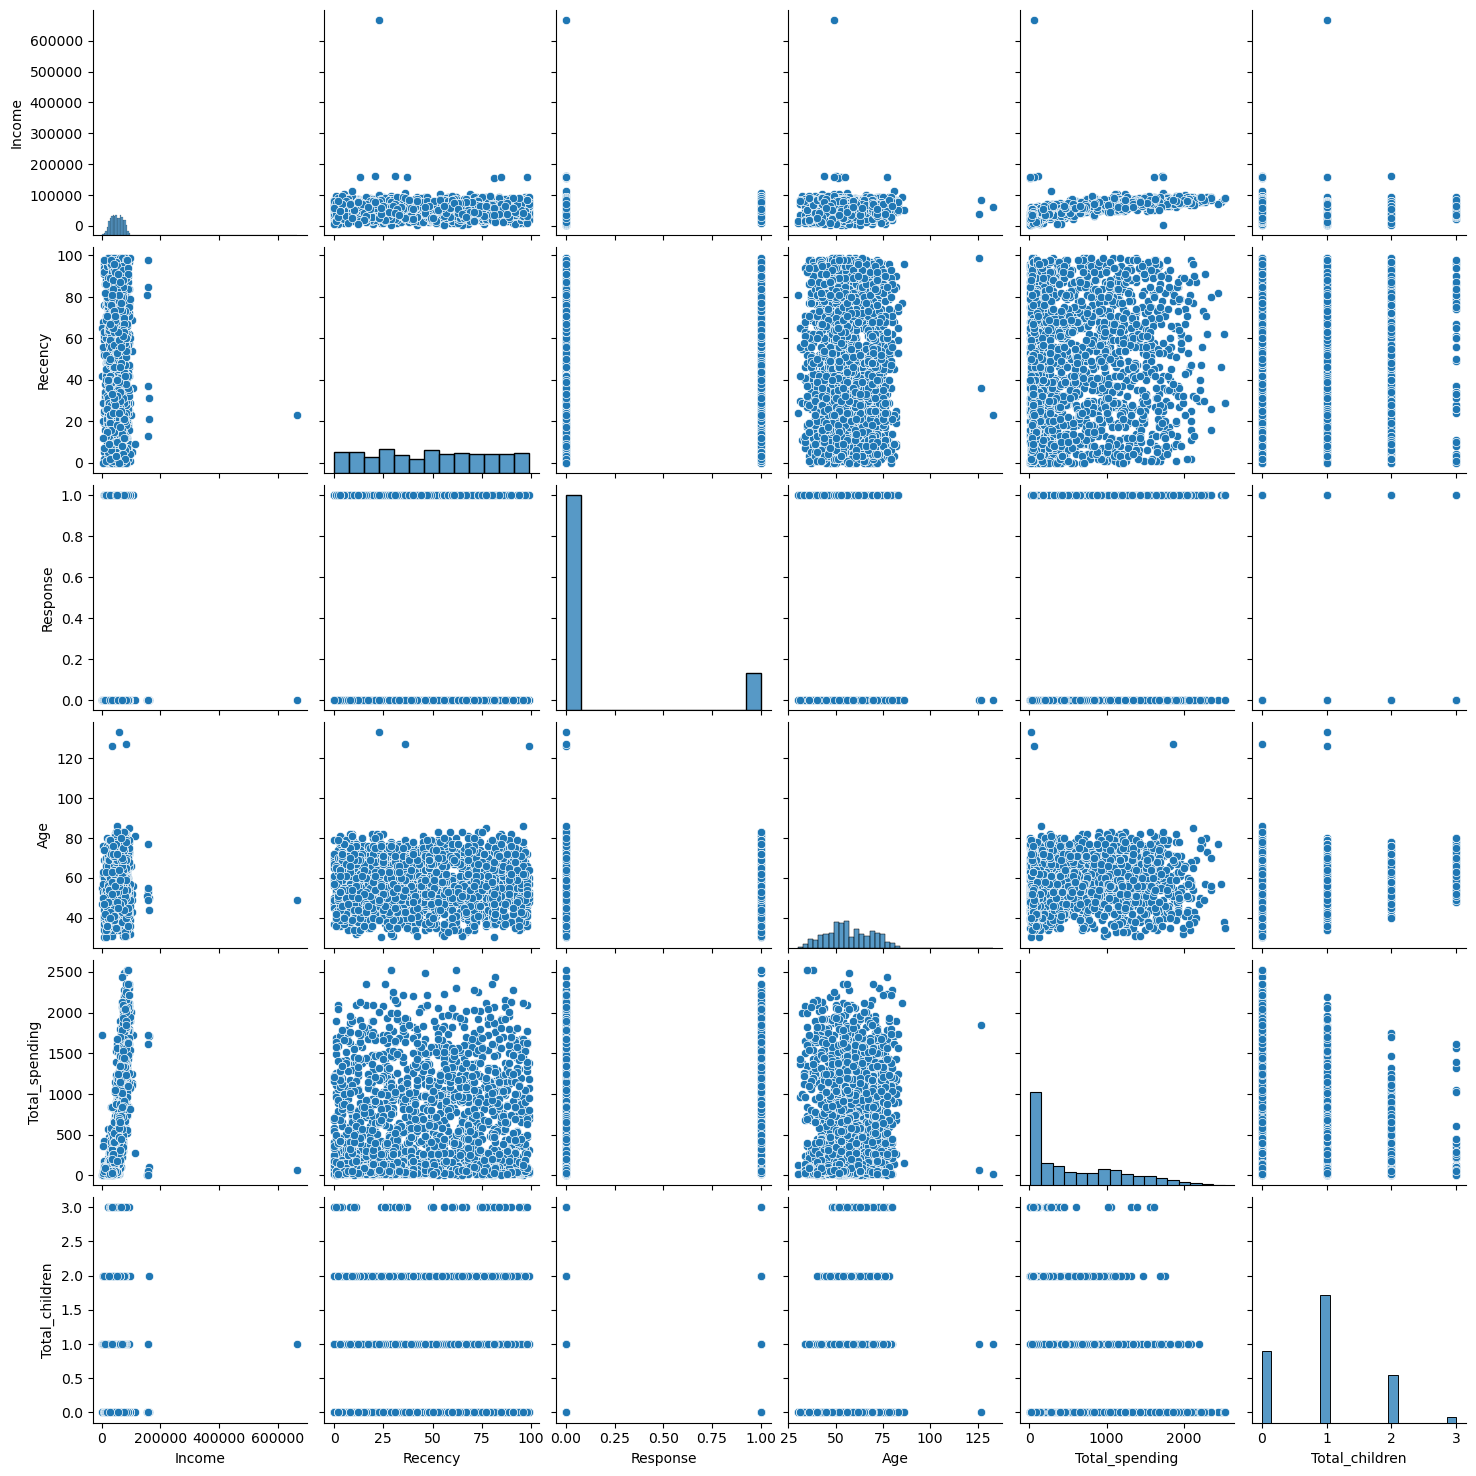

In [131]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_children"]

# relative plots of some features
sns.pairplot(df_cleaned[cols])

In [132]:
# remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned [(df_cleaned ["Age"] < 90)]
df_cleaned = df_cleaned [(df_cleaned ["Income"] < 600_000)]



data size with outliers: 2240


#heatmap

In [71]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

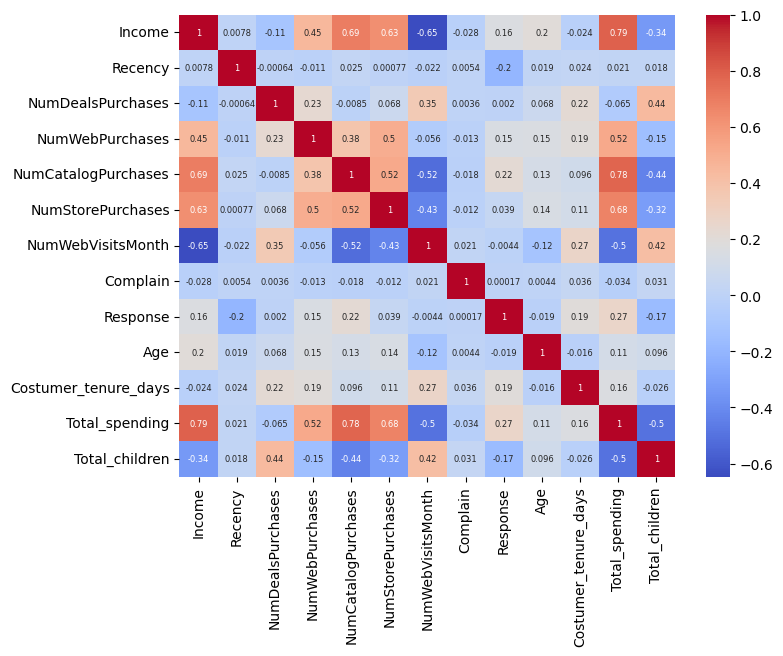

In [73]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

Encoding

In [133]:
from  sklearn.preprocessing import OneHotEncoder

In [134]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [88]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [89]:
enc_df.head()

,Education_2n Cycle,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,1.0


In [90]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [101]:
df_encoded.shape

(2236, 19)

#scaling

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
X = df_encoded

In [106]:
scaler =  StandardScaler()

X_scaler = scaler.fit_transform(X)

#visualize

In [108]:
X_scaler.shape

(2236, 19)

In [109]:
from sklearn.decomposition import PCA

In [117]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaler)

In [118]:
pca.explained_variance_ratio_

array([0.22035061, 0.10797909, 0.0986477 ])

Text(0.5, 0.92, '3d projection')

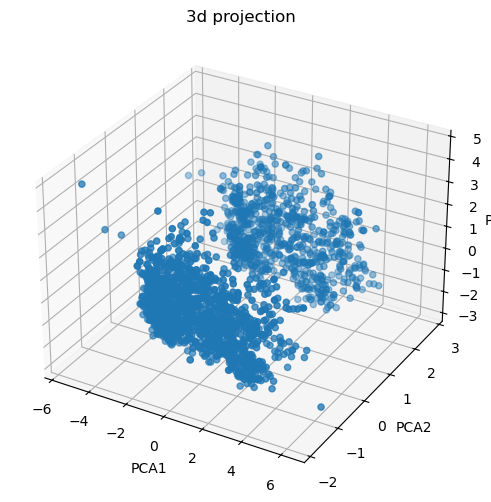

In [123]:
#plot

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

#analysis K value

1. Elbow Method

In [141]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range (1,11):
    kmeans = KMeans(n_clusters=k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [144]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [145]:
print("best k = ", optimal_k)

best k =  3


Text(0, 0.5, 'wcss')

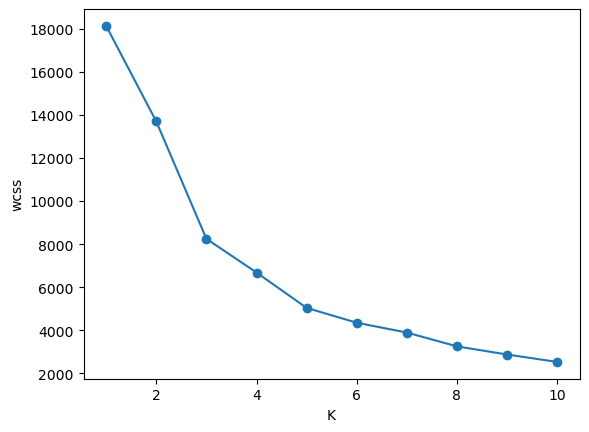

In [149]:
plt.plot(range (1,11) , wcss , marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

2. silhouette score

Text(0, 0.5, 'silhouette_score')

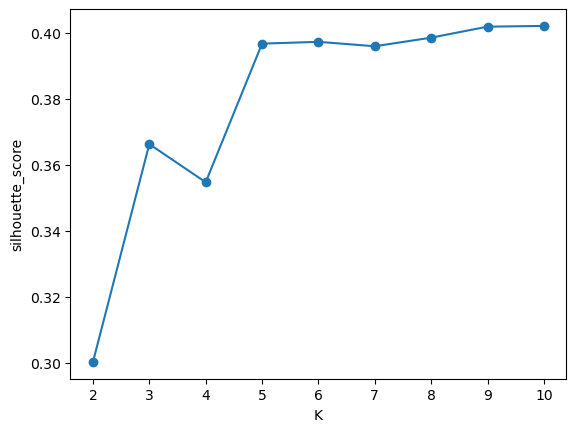

In [150]:
from sklearn.metrics import silhouette_score

scores = []

for k in range (2,11):
    kmeans = KMeans(n_clusters=k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

#plot
plt.plot(range(2,11), scores , marker='o')
plt.xlabel("K")
plt.ylabel("silhouette_score")
   

Text(0, 0.5, 'SS')

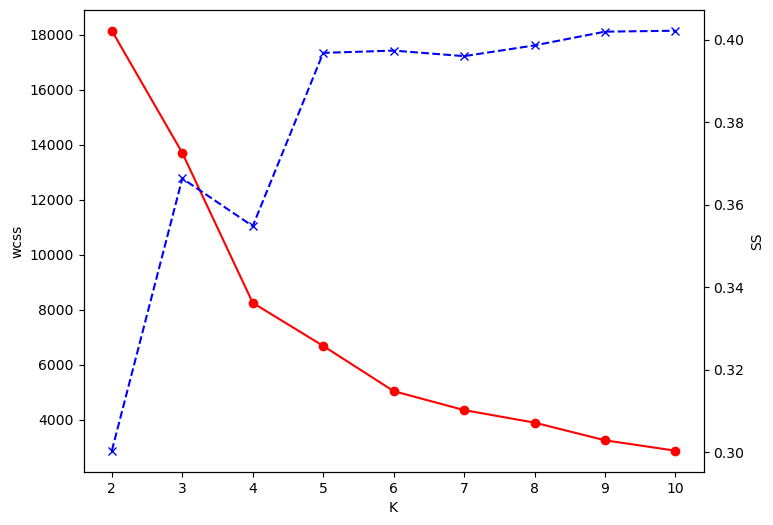

In [157]:
#combined plot

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker ="o" , color = "red")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)] , marker = "x" , color = "blue", linestyle="--")
ax2.set_ylabel("SS")

Clustering